# Coffe Quality prediction

Our Arabica coffee dataset is highly imbalanced, with 86% Specialty samples and just 13% Below Specialty samples. To properly approach this imbalance, we will implement  two strategies:

 - Handle the data splitting using stratified data splitting, so we have the same ratio in tour training, and testing sets.
 - We employ accuracy metrics that look how well the model handles the minority class, we employ precision, recall and the F1-score




In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from xgboost import XGBClassifier


from sklearn.metrics import classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 55

project_root = Path.cwd().parent

# Dataset

We have 1069 coffee samples with 8 selected features: variety, processing_method, moisture, defect counts, color, and altitude.
The target variable is `Total.Cup.Points`.

In [41]:

# Function to define the threshold between Below Specialty and Specialty
def cup_score_class(score):
    if score < 80:   
        return 1
    else: 
        return 0

coffe_data_path = project_root / "data" / "cleaned_coffee_data.csv"   
df = pd.read_csv(coffe_data_path)
X = df.drop(columns= "Total.Cup.Points").copy()
y = df["Total.Cup.Points"].copy()
y = y.apply(cup_score_class)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X.head()


X shape: (1296, 8)
y shape: (1296,)


,altitude_mean_meters,Moisture,Category.One.Defects,Category.Two.Defects,Quakers,Variety,Processing.Method,Color
0,2075.0,0.12,0,0,0.0,NaN,Washed / Wet,Green
1,2075.0,0.12,0,1,0.0,Other,Washed / Wet,Green
2,1700.0,0.00,0,0,0.0,Bourbon,NaN,NaN
3,2000.0,0.11,0,2,0.0,NaN,Natural / Dry,Green
4,2075.0,0.12,0,2,0.0,Other,Washed / Wet,Green


Here, we can clearly see the imbalance of our dataset:

Total.Cup.Points
0    1118
1     178
Name: count, dtype: int64

Percentages:
Total.Cup.Points
0    86.3
1    13.7
Name: proportion, dtype: float64


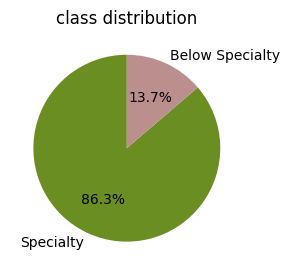

In [42]:
print(y.value_counts())
print(f"\nPercentages:")
print((y.value_counts(normalize=True)*100).round(1))


class_counts = y.value_counts()
plt.figure(figsize=(3, 3))
plt.pie(class_counts,labels=["Specialty", "Below Specialty",], autopct='%1.1f%%', 
    startangle=90,colors = ['olivedrab', 'rosybrown'])
plt.title("class distribution")
plt.tight_layout()
plt.show()

# Splitting the Dataset

We proceed to split the dataset by keeping the same ratio (SPecialty/Below Specialty) in both datasets setting 'stratify =y'

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=RANDOM_STATE, stratify =y
)
print(f"tran sample: {X_train.shape}, test samples: {X_test.shape}")

tran sample: (1036, 8), test samples: (260, 8)


We define an approach to deal with the missing values of the numerical and categorical features:

In [44]:

median_num_features = ["altitude_mean_meters", "Moisture"]
zero_num_features = ["Category.One.Defects", "Category.Two.Defects", "Quakers"]

categorical_features = ["Variety", "Processing.Method", "Color"]

median_numerical_pipeline = Pipeline([
    ("impute_median", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

zero_numerical_pipeline = Pipeline([
    ("impute_zero", SimpleImputer(strategy="constant", fill_value=0)),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("impute_unknown", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False, max_categories=10)),
])

preprocessor = ColumnTransformer([
    ("num_median", median_numerical_pipeline, median_num_features),
    ("num_zero", zero_numerical_pipeline, zero_num_features),
    ("categorical", categorical_pipeline, categorical_features )
])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Logistic Regression 



In [45]:

lr_model = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE)

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred, target_names=['Specialty (0)', 'Below Specialty (1)']))

[[155  69]
 [ 11  25]]
                     precision    recall  f1-score   support

      Specialty (0)       0.93      0.69      0.79       224
Below Specialty (1)       0.27      0.69      0.38        36

           accuracy                           0.69       260
          macro avg       0.60      0.69      0.59       260
       weighted avg       0.84      0.69      0.74       260



The model's recall is balanced, catching roughly 69% of the actual cases for each class. On the other hand, precision for Below Specialty is quite low, meaning, when the model predicts a coffee is Below Specialty, it is right only 27% of the time, the other 73% of the time is flagging specialty coffee as below specialty.

To optimize the model fairly fot both classes, we will focus on improving the macro average F1-score, which treats both classes equally. 

## hyperparameter tuning (regularization)

Best C value: {'C': 0.01}
              precision    recall  f1-score   support

           0      0.914     0.808     0.858       224
           1      0.306     0.528     0.388        36

    accuracy                          0.769       260
   macro avg      0.610     0.668     0.623       260
weighted avg      0.830     0.769     0.793       260



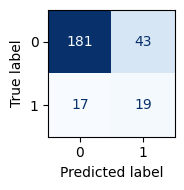

In [46]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1', 
    n_jobs=-1
)
grid.fit(X_train, y_train)
print(f"Best C value: {grid.best_params_}")

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, digits=3))

fig, ax = plt.subplots(figsize=(2, 2))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, labels=[0, 1], cmap="Blues", ax=ax, colorbar=False
)
plt.tight_layout()
plt.show()

The search for the optimal regularization parameter gave C=0.01, smaller than the default C=1, meaning we introduce a stronger regularization. As a result, precision for 'Below Specialty' increased from 27% to 30%, throwing fewer false alarms.  

Overall, the macro F1 score increased from 0.59 to 0.623, proving the model achieved a better balanced across both classses.

# Random Forest Classifier

Random Forest classification report:
              precision    recall  f1-score   support

           0      0.894     0.906     0.900       224
           1      0.364     0.333     0.348        36

    accuracy                          0.827       260
   macro avg      0.629     0.620     0.624       260
weighted avg      0.821     0.827     0.824       260



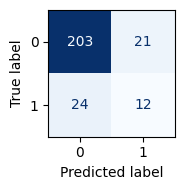

In [30]:
rf_class_model= RandomForestClassifier(
        n_estimators=50,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

rf_class_model.fit(X_train, y_train)
y_pred_rf = rf_class_model.predict(X_test)

print("Random Forest classification report:")
print(classification_report(y_test, y_pred_rf, digits=3))

fig, ax = plt.subplots(figsize=(2,2))
ConfusionMatrixDisplay.from_estimator(
    rf_class_model, X_test, y_test, labels=[0,1], cmap="Blues", ax=ax,colorbar=False
)

plt.tight_layout()
plt.show()

The macro F1 for the class 0 is = 0.4, confirming the model struggles to identify below-speciality. This is expected given the limited training examples for the class '0'.

##  Hyperparameter tuning

We start by choosing the best n_estimators, which defines the number of Decision trees that ake up our Random Forest.

Text(0, 0.5, 'f1_score')

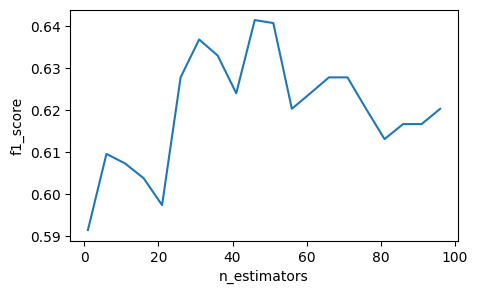

In [31]:

n_values = np.arange(1,101,5)
accuracy_list_train = []
accuracy_list_test = []
f1_list = []

for n_est in n_values:
    rf_model= RandomForestClassifier(
        n_estimators=n_est,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_model.fit(X_train, y_train)
    y_pred_test = rf_model.predict(X_test) #test
    f1_list.append(f1_score(y_test,y_pred_test, average='macro'))

plt.figure(figsize=(5, 3))
plt.plot(n_values,f1_list)
plt.xlabel('n_estimators')
plt.ylabel('f1_score')

n_estimators= 50 gives us the highest f1_score, however by leaving the other hyperparameters at their fixed of default values.

To check every combination, we use GridSearchCV.


In [32]:
param_grid = {
    "n_estimators": [10, 50, 100, 200,300,400],
    "min_samples_split": [ 2, 5, 15, 30,45],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_depth": [None, 2, 3],
}
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_grid=param_grid,
    scoring="f1_macro",  
    cv=5,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best CV f1_macro: 0.6897


              precision    recall  f1-score   support

           0      0.899     0.911     0.905       224
           1      0.394     0.361     0.377        36

    accuracy                          0.835       260
   macro avg      0.646     0.636     0.641       260
weighted avg      0.829     0.835     0.832       260



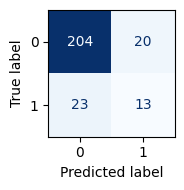

In [33]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, digits=3))

fig, ax = plt.subplots(figsize=(2, 2))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, labels=[0, 1], cmap="Blues", ax=ax, colorbar=False
)
plt.tight_layout()
plt.show()

# XGBoost Classifier

We test XGBoost as it gives preference to the training examples that did not do well.

In [34]:
n = int(len(X_train)*0.8)
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n], X_train[n:], y_train[:n], y_train[n:]

xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = RANDOM_STATE,  early_stopping_rounds = 10)
xgb_model.fit(X_train_fit,y_train_fit, eval_set = [(X_train_eval,y_train_eval)])


[0]	validation_0-logloss:0.44874
[1]	validation_0-logloss:0.44035
[2]	validation_0-logloss:0.43282
[3]	validation_0-logloss:0.42597
[4]	validation_0-logloss:0.41990
[5]	validation_0-logloss:0.41249
[6]	validation_0-logloss:0.40781
[7]	validation_0-logloss:0.40527
[8]	validation_0-logloss:0.40211
[9]	validation_0-logloss:0.39543
[10]	validation_0-logloss:0.38978
[11]	validation_0-logloss:0.38666
[12]	validation_0-logloss:0.38018
[13]	validation_0-logloss:0.37553
[14]	validation_0-logloss:0.37316
[15]	validation_0-logloss:0.36832
[16]	validation_0-logloss:0.36522
[17]	validation_0-logloss:0.36454
[18]	validation_0-logloss:0.36373
[19]	validation_0-logloss:0.36110
[20]	validation_0-logloss:0.36111
[21]	validation_0-logloss:0.36130
[22]	validation_0-logloss:0.36042
[23]	validation_0-logloss:0.35861
[24]	validation_0-logloss:0.35864
[25]	validation_0-logloss:0.35740
[26]	validation_0-logloss:0.35740
[27]	validation_0-logloss:0.35667
[28]	validation_0-logloss:0.35707
[29]	validation_0-loglos

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,10
,enable_categorical,False
,eval_metric,None


In [35]:
print(xgb_model.best_iteration)
print(classification_report(y_test, xgb_model.predict(X_test), digits=3))


27
              precision    recall  f1-score   support

           0      0.871     0.969     0.918       224
           1      0.364     0.111     0.170        36

    accuracy                          0.850       260
   macro avg      0.618     0.540     0.544       260
weighted avg      0.801     0.850     0.814       260



All models overall strugle with the class 0, however XGBoost gives a higher macro F1 score than Random Forest.